# Phase 7 — Closing the Gap (0.910 → 0.951)
## Targeted Improvements to Climb the Leaderboard

**Current situation:**
| Rank | Name | Score |
|------|------|-------|
| 1 | gianburn | 0.95081 |
| 2 | Kuzey Yeniay | 0.91325 |
| 3 | Ali Vaezi | 0.90974 |

**Gap to close:** 0.041 F1 (4.1 percentage points)

### Improvement Strategy

| # | Technique | Expected Gain | Why |
|---|-----------|--------------|-----|
| 1 | **DeBERTa K-Fold** (5-fold full OOF) | +2-3% | Current: single split (70/15/15). Only 30% OOF coverage for stacking. K-fold gives 100% OOF → much better meta-learner |
| 2 | **DeBERTa-v3-large** | +1-2% | Larger model = better minority class discrimination. 304M vs 86M params |
| 3 | **Multi-model transformer ensemble** | +1-2% | Add RoBERTa-large or another DeBERTa checkpoint for diversity |
| 4 | **Enhanced stacking** with more meta-features | +0.5-1% | Add confidence, entropy, class-level features to meta-learner |
| 5 | **Pseudo-label iteration** | +0.5-1% | Use high-confidence test predictions to augment training |
| 6 | **Test-Time Augmentation** | +0.3-0.5% | Ensemble predictions from slightly different text preprocessing |

### Plan of Attack
We'll implement improvements **incrementally** and submit after each to track leaderboard progress.

**Phase 7A:** DeBERTa-v3-base 5-fold → better OOF → better stacking  
**Phase 7B:** Add DeBERTa-v3-large as second transformer  
**Phase 7C:** Enhanced stacking with richer meta-features  
**Phase 7D:** Pseudo-labeling + TTA

In [1]:
import os, warnings, gc, time, json, re, string, hashlib, sys
os.chdir('/Users/aliivaezii/Documents/MALTO')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from scipy import sparse

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import joblib

SEED = 42
NUM_LABELS = 6
LABEL_MAP = {0: 'Human', 1: 'DeepSeek', 2: 'Grok', 3: 'Claude', 4: 'Gemini', 5: 'ChatGPT'}

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)

gc.collect()
DEVICE = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
if DEVICE.type == 'mps':
    torch.mps.empty_cache()

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
y_all = train_df['LABEL'].values
texts_train = train_df['TEXT'].values
texts_test = test_df['TEXT'].values

print(f'Device: {DEVICE}')
print(f'Train: {train_df.shape}, Test: {test_df.shape}')
print(f'Labels: {dict(zip(*np.unique(y_all, return_counts=True)))}')

Device: mps
Train: (2400, 2), Test: (600, 2)
Labels: {np.int64(0): np.int64(1520), np.int64(1): np.int64(80), np.int64(2): np.int64(160), np.int64(3): np.int64(80), np.int64(4): np.int64(240), np.int64(5): np.int64(320)}


## Phase 7A: DeBERTa-v3-base 5-Fold Training

**Why this is the #1 improvement:**

Currently DeBERTa uses a single train/val/cal split:
- Train on 70% (1680 samples)
- OOF predictions on only 30% (720 samples)
- Stacking meta-learner sees only 720 samples

With **5-fold CV**:
- Each fold trains on 80% (1920 samples) — **240 more training samples per fold**
- OOF predictions on **100%** (2400 samples)
- Stacking meta-learner sees **2400 samples** (3.3× more)
- 5 different models → averaged test predictions (reduces variance)

This is almost certainly what the 1st place solution does.

In [2]:
# ============================================================
# MODEL & TRAINING CONFIG
# ============================================================
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN = 512
BATCH_SIZE = 2
GRAD_ACCUM = 8  # effective batch = 16
EPOCHS = 5
LR = 3e-5
WEIGHT_DECAY = 0.01
PATIENCE = 2
NUM_WORKERS = 0
N_FOLDS = 5

print(f'Model: {MODEL_NAME}')
print(f'Config: MAX_LEN={MAX_LEN}, BATCH={BATCH_SIZE}x{GRAD_ACCUM}=eff {BATCH_SIZE*GRAD_ACCUM}')
print(f'Training: {N_FOLDS}-fold CV, EPOCHS={EPOCHS}, PATIENCE={PATIENCE}')
print(f'LR={LR}, WEIGHT_DECAY={WEIGHT_DECAY}')

Model: microsoft/deberta-v3-base
Config: MAX_LEN=512, BATCH=2x8=eff 16
Training: 5-fold CV, EPOCHS=5, PATIENCE=2
LR=3e-05, WEIGHT_DECAY=0.01


In [3]:
# ============================================================
# TOKENIZE ALL DATA ONCE
# ============================================================
print('Tokenizing all data...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    list(texts_train), truncation=True, padding=True,
    max_length=MAX_LEN, return_tensors='pt'
)
test_encodings = tokenizer(
    list(texts_test), truncation=True, padding=True,
    max_length=MAX_LEN, return_tensors='pt'
)

# Check truncation
n_trunc = sum(1 for ids in train_encodings['input_ids'] if ids[-1] != tokenizer.pad_token_id)
print(f'Tokenization done. Truncated: {n_trunc}/{len(texts_train)} train texts')
print(f'Train tokens shape: {train_encodings["input_ids"].shape}')
print(f'Test tokens shape: {test_encodings["input_ids"].shape}')

Tokenizing all data...
Tokenization done. Truncated: 1001/2400 train texts
Train tokens shape: torch.Size([2400, 512])
Test tokens shape: torch.Size([600, 512])


In [4]:
# ============================================================
# DATASET & LOSS
# ============================================================
class PreTokenizedDataset(Dataset):
    def __init__(self, encodings, labels=None, indices=None):
        self.encodings = encodings
        self.labels = labels
        self.indices = indices

    def __len__(self):
        return len(self.indices) if self.indices is not None else len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        real_idx = self.indices[idx] if self.indices is not None else idx
        item = {key: val[real_idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[real_idx], dtype=torch.long)
        return item


class FocalLoss(nn.Module):
    """Focal Loss -- focuses on hard examples, great for imbalanced data."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def get_optimizer_with_llrd(model, lr, weight_decay=0.01, llrd_factor=0.9):
    """Layer-wise Learning Rate Decay."""
    opt_params = []
    no_decay = ['bias', 'LayerNorm.weight', 'layernorm.weight']

    # Classifier head gets full LR
    head_params_wd = [p for n, p in model.named_parameters()
        if ('classifier' in n or 'pooler' in n) and not any(nd in n for nd in no_decay)]
    head_params_nowd = [p for n, p in model.named_parameters()
        if ('classifier' in n or 'pooler' in n) and any(nd in n for nd in no_decay)]
    opt_params.append({'params': head_params_wd, 'lr': lr, 'weight_decay': weight_decay})
    opt_params.append({'params': head_params_nowd, 'lr': lr, 'weight_decay': 0.0})

    num_layers = model.config.num_hidden_layers
    for layer_idx in range(num_layers - 1, -1, -1):
        layer_lr = lr * (llrd_factor ** (num_layers - 1 - layer_idx))
        layer_params_wd = [p for n, p in model.named_parameters()
            if f'encoder.layer.{layer_idx}.' in n and not any(nd in n for nd in no_decay)]
        layer_params_nowd = [p for n, p in model.named_parameters()
            if f'encoder.layer.{layer_idx}.' in n and any(nd in n for nd in no_decay)]
        if layer_params_wd:
            opt_params.append({'params': layer_params_wd, 'lr': layer_lr, 'weight_decay': weight_decay})
        if layer_params_nowd:
            opt_params.append({'params': layer_params_nowd, 'lr': layer_lr, 'weight_decay': 0.0})

    emb_lr = lr * (llrd_factor ** num_layers)
    emb_params_wd = [p for n, p in model.named_parameters()
        if 'embeddings' in n and not any(nd in n for nd in no_decay)]
    emb_params_nowd = [p for n, p in model.named_parameters()
        if 'embeddings' in n and any(nd in n for nd in no_decay)]
    if emb_params_wd:
        opt_params.append({'params': emb_params_wd, 'lr': emb_lr, 'weight_decay': weight_decay})
    if emb_params_nowd:
        opt_params.append({'params': emb_params_nowd, 'lr': emb_lr, 'weight_decay': 0.0})

    assigned = set()
    for group in opt_params:
        for p in group['params']:
            assigned.add(id(p))
    remaining_wd = [p for n, p in model.named_parameters()
        if id(p) not in assigned and not any(nd in n for nd in no_decay)]
    remaining_nowd = [p for n, p in model.named_parameters()
        if id(p) not in assigned and any(nd in n for nd in no_decay)]
    if remaining_wd:
        opt_params.append({'params': remaining_wd, 'lr': lr * 0.5, 'weight_decay': weight_decay})
    if remaining_nowd:
        opt_params.append({'params': remaining_nowd, 'lr': lr * 0.5, 'weight_decay': 0.0})

    return torch.optim.AdamW(opt_params)


print('Dataset, FocalLoss, and LLRD optimizer ready.')

Dataset, FocalLoss, and LLRD optimizer ready.


In [5]:
# ============================================================
# 5-FOLD DEBERTA TRAINING
# ============================================================
def train_one_fold(fold_idx, train_idx, val_idx, class_weights):
    """Train DeBERTa for one fold. Returns val logits, test logits, and best F1."""
    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx + 1}/{N_FOLDS}')
    print(f'  Train: {len(train_idx)}, Val: {len(val_idx)}')
    print(f'{"="*60}')

    train_ds = PreTokenizedDataset(train_encodings, y_all, train_idx)
    val_ds = PreTokenizedDataset(train_encodings, y_all, val_idx)
    test_ds = PreTokenizedDataset(test_encodings)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, num_workers=NUM_WORKERS)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
    )
    model.to(DEVICE)

    criterion = FocalLoss(alpha=class_weights, gamma=2.0)
    optimizer = get_optimizer_with_llrd(model, lr=LR, llrd_factor=0.9)

    total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
    scheduler = get_scheduler('cosine', optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps)

    best_f1 = 0
    best_state = None
    patience_counter = 0

    for epoch in range(EPOCHS):
        t0 = time.time()

        # --- TRAIN ---
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
            desc=f'F{fold_idx+1} E{epoch+1} [Train]', leave=False,
            bar_format='{l_bar}{bar:30}{r_bar}')

        for step, batch in pbar:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = inputs.pop('labels')
            outputs = model(**inputs)
            loss = criterion(outputs.logits, labels) / GRAD_ACCUM
            loss.backward()
            total_loss += loss.item() * GRAD_ACCUM

            if (step + 1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            pbar.set_postfix({'loss': f'{total_loss/(step+1):.4f}'})

        pbar.close()

        # Flush remaining gradients
        if (step + 1) % GRAD_ACCUM != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        avg_loss = total_loss / len(train_loader)

        # --- VALIDATE ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                inputs = {k: v.to(DEVICE) for k, v in batch.items()}
                labels = inputs.pop('labels')
                outputs = model(**inputs)
                all_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        elapsed = time.time() - t0

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = '  new best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{PATIENCE})'

        print(f'  E{epoch+1} | loss={avg_loss:.4f} | val_f1={val_f1:.4f} | {elapsed:.0f}s{marker}')

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    # Load best and predict
    model.load_state_dict(best_state)
    model.eval()

    val_logits_list = []
    with torch.no_grad():
        for batch in val_loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            inputs.pop('labels', None)
            outputs = model(**inputs)
            val_logits_list.extend(outputs.logits.cpu().numpy())

    test_logits_list = []
    with torch.no_grad():
        for batch in test_loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**inputs)
            test_logits_list.extend(outputs.logits.cpu().numpy())

    # Save fold checkpoint
    torch.save(model.state_dict(), f'checkpoints/deberta_fold{fold_idx}.pt')

    # Cleanup
    del model, optimizer, scheduler, best_state
    gc.collect()
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()

    return np.array(val_logits_list), np.array(test_logits_list), best_f1


print('Training function ready for 5-fold.')

Training function ready for 5-fold.


In [6]:
# ============================================================
# RUN 5-FOLD TRAINING
# ============================================================
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for OOF predictions and averaged test predictions
deberta_oof_logits = np.zeros((len(y_all), NUM_LABELS))
deberta_test_logits_sum = np.zeros((len(test_df), NUM_LABELS))
fold_scores = []

os.makedirs('checkpoints', exist_ok=True)
t_start = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(y_all)), y_all)):
    # Compute class weights from THIS fold's training data
    train_counts = pd.Series(y_all[train_idx]).value_counts().sort_index().values
    cw = 1.0 / train_counts
    cw = cw / cw.sum() * NUM_LABELS
    class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

    val_logits, test_logits, best_f1 = train_one_fold(fold_idx, train_idx, val_idx, class_weights)

    # Store OOF logits
    deberta_oof_logits[val_idx] = val_logits
    deberta_test_logits_sum += test_logits
    fold_scores.append(best_f1)

    print(f'  Fold {fold_idx+1} best val F1: {best_f1:.4f}')
    print(f'  Running time: {(time.time()-t_start)/60:.1f} min')

# Average test logits across folds
deberta_test_logits_avg = deberta_test_logits_sum / N_FOLDS

t_total = time.time() - t_start
print(f'\n{"="*60}')
print(f'5-FOLD TRAINING COMPLETE')
print(f'  Fold scores: {[f"{s:.4f}" for s in fold_scores]}')
print(f'  Mean: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'  Total time: {t_total/60:.1f} min')
print(f'{"="*60}')


FOLD 1/5
  Train: 1920, Val: 480


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  E1 | loss=0.2113 | val_f1=0.7569 | 1288s  new best


  E2 | loss=0.0413 | val_f1=0.8962 | 1359s  new best


  E3 | loss=0.0185 | val_f1=0.9030 | 1353s  new best


...

  E1 | loss=0.1934 | val_f1=0.7019 | 668s  new best


  E2 | loss=0.0505 | val_f1=0.8292 | 673s  new best


  E3 | loss=0.0243 | val_f1=0.9093 | 673s  new best


  E4 | loss=0.0053 | val_f1=0.9419 | 664s  new best


  E5 | loss=0.0013 | val_f1=0.9272 | 674s (patience 1/2)
  Fold 5 best val F1: 0.9419
  Running time: 363.1 min

5-FOLD TRAINING COMPLETE
  Fold scores: ['0.9202', '0.9495', '0.9556', '0.9455', '0.9419']
  Mean: 0.9425 ± 0.0121
  Total time: 363.1 min


In [7]:
# ============================================================
# TEMPERATURE SCALING ON OOF
# ============================================================
# Find optimal temperature using OOF logits vs true labels
logits_t = torch.tensor(deberta_oof_logits, dtype=torch.float32)
labels_t = torch.tensor(y_all, dtype=torch.long)

best_temp = 1.0
best_nll = float('inf')

for temp in np.arange(0.3, 5.0, 0.05):
    scaled = logits_t / temp
    nll = nn.functional.cross_entropy(scaled, labels_t).item()
    if nll < best_nll:
        best_nll = nll
        best_temp = temp

print(f'Optimal temperature: {best_temp:.2f}')

# Compute calibrated OOF probabilities
deberta_oof_probs = torch.softmax(logits_t / best_temp, dim=-1).numpy()
deberta_oof_preds = deberta_oof_probs.argmax(axis=1)
deberta_oof_f1 = f1_score(y_all, deberta_oof_preds, average='macro')

# Compute calibrated test probabilities
deberta_test_probs = torch.softmax(
    torch.tensor(deberta_test_logits_avg, dtype=torch.float32) / best_temp, dim=-1
).numpy()
deberta_test_preds = deberta_test_probs.argmax(axis=1)

print(f'DeBERTa 5-fold OOF F1: {deberta_oof_f1:.4f}')
print(f'(Previous single-split val F1 was 0.9151)')
print(f'\nOOF per-class report:')
print(classification_report(y_all, deberta_oof_preds,
    target_names=[f'{v}({k})' for k, v in LABEL_MAP.items()]))

print(f'Test distribution: {dict(zip(*np.unique(deberta_test_preds, return_counts=True)))}')

Optimal temperature: 0.40
DeBERTa 5-fold OOF F1: 0.9428
(Previous single-split val F1 was 0.9151)

OOF per-class report:
              precision    recall  f1-score   support

    Human(0)       1.00      1.00      1.00      1520
 DeepSeek(1)       0.76      0.81      0.79        80
     Grok(2)       0.90      0.88      0.89       160
   Claude(3)       1.00      0.99      0.99        80
   Gemini(4)       0.98      1.00      0.99       240
  ChatGPT(5)       1.00      1.00      1.00       320

    accuracy                           0.98      2400
   macro avg       0.94      0.95      0.94      2400
weighted avg       0.98      0.98      0.98      2400

Test distribution: {np.int64(0): np.int64(379), np.int64(1): np.int64(26), np.int64(2): np.int64(34), np.int64(3): np.int64(20), np.int64(4): np.int64(60), np.int64(5): np.int64(81)}


In [8]:
# ============================================================
# SAVE DeBERTa 5-FOLD ARTIFACTS
# ============================================================
os.makedirs('models', exist_ok=True)

np.save('models/deberta_kfold_oof_logits.npy', deberta_oof_logits)
np.save('models/deberta_kfold_oof_probs.npy', deberta_oof_probs)
np.save('models/deberta_kfold_test_logits.npy', deberta_test_logits_avg)
np.save('models/deberta_kfold_test_probs.npy', deberta_test_probs)

kfold_config = {
    'model_name': MODEL_NAME,
    'n_folds': N_FOLDS,
    'temperature': float(best_temp),
    'oof_f1': float(deberta_oof_f1),
    'fold_scores': [float(s) for s in fold_scores],
    'mean_fold_f1': float(np.mean(fold_scores)),
    'std_fold_f1': float(np.std(fold_scores)),
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'grad_accum': GRAD_ACCUM,
    'lr': LR,
    'epochs': EPOCHS,
    'total_time_min': round(t_total / 60, 1),
}
with open('models/deberta_kfold_config.json', 'w') as f:
    json.dump(kfold_config, f, indent=2)

print('Saved all 5-fold DeBERTa artifacts.')
print(json.dumps(kfold_config, indent=2))

Saved all 5-fold DeBERTa artifacts.
{
  "model_name": "microsoft/deberta-v3-base",
  "n_folds": 5,
  "temperature": 0.39999999999999997,
  "oof_f1": 0.9427577127730067,
  "fold_scores": [
    0.9201704373193224,
    0.9495223640470672,
    0.9555555555555556,
    0.9455481961384731,
    0.941864680237258
  ],
  "mean_fold_f1": 0.9425322466595352,
  "std_fold_f1": 0.012066983292010726,
  "max_len": 512,
  "batch_size": 2,
  "grad_accum": 8,
  "lr": 3e-05,
  "epochs": 5,
  "total_time_min": 363.1
}


## Phase 7B: Enhanced Stacking with Full OOF

Now we have **100% OOF coverage** from all models:
- DeBERTa 5-fold: 2400/2400 OOF predictions
- SVC 5-fold: 2400/2400 OOF predictions (from Phase 4)
- LR 5-fold: 2400/2400 OOF predictions (from Phase 4)

The stacking meta-learner can now train on **all 2400 samples** instead of just 720.

Additionally, we enhance the meta-features with:
- Raw probabilities (18 features)
- Per-model confidence (max prob) — 3 features
- Per-model entropy — 3 features
- Probability differences between models — 3 features
- **Total: 27+ meta-features**

In [9]:
# ============================================================
# LOAD SVC/LR OOF PROBS FROM PHASE 4
# ============================================================
svc_oof_probs = np.load('models/ensemble_svc_oof_probs.npy')
lr_oof_probs = np.load('models/ensemble_lr_oof_probs.npy')
svc_test_probs = np.load('models/ensemble_svc_test_probs_cv.npy')
lr_test_probs = np.load('models/ensemble_lr_test_probs_cv.npy')

# Verify shapes
print(f'DeBERTa OOF: {deberta_oof_probs.shape} (100% coverage!)')
print(f'SVC OOF:     {svc_oof_probs.shape}')
print(f'LR OOF:      {lr_oof_probs.shape}')

# Base model OOF F1s
svc_oof_f1 = f1_score(y_all, svc_oof_probs.argmax(axis=1), average='macro')
lr_oof_f1 = f1_score(y_all, lr_oof_probs.argmax(axis=1), average='macro')

print(f'\nBase model OOF F1 (all on full 2400 samples):')
print(f'  DeBERTa 5-fold: {deberta_oof_f1:.4f}')
print(f'  SVC:            {svc_oof_f1:.4f}')
print(f'  LR:             {lr_oof_f1:.4f}')

DeBERTa OOF: (2400, 6) (100% coverage!)
SVC OOF:     (2400, 6)
LR OOF:      (2400, 6)

Base model OOF F1 (all on full 2400 samples):
  DeBERTa 5-fold: 0.9428
  SVC:            0.8979
  LR:             0.9026


In [10]:
# ============================================================
# BUILD ENHANCED META-FEATURES
# ============================================================
def build_meta_features(deberta_probs, svc_probs, lr_probs):
    """Build rich meta-features for the stacking meta-learner."""
    n = len(deberta_probs)
    features = []

    # 1. Raw probabilities (3 x 6 = 18 features)
    features.append(deberta_probs)
    features.append(svc_probs)
    features.append(lr_probs)

    # 2. Per-model confidence = max probability (3 features)
    features.append(deberta_probs.max(axis=1, keepdims=True))
    features.append(svc_probs.max(axis=1, keepdims=True))
    features.append(lr_probs.max(axis=1, keepdims=True))

    # 3. Per-model entropy (3 features)
    for probs in [deberta_probs, svc_probs, lr_probs]:
        ent = -np.sum(probs * np.log(np.clip(probs, 1e-10, 1.0)), axis=1, keepdims=True)
        features.append(ent)

    # 4. Pairwise probability differences: max abs diff per class (3 features)
    features.append(np.abs(deberta_probs - svc_probs).max(axis=1, keepdims=True))
    features.append(np.abs(deberta_probs - lr_probs).max(axis=1, keepdims=True))
    features.append(np.abs(svc_probs - lr_probs).max(axis=1, keepdims=True))

    # 5. Agreement features: do models agree on the top class? (3 features)
    d_pred = deberta_probs.argmax(axis=1)
    s_pred = svc_probs.argmax(axis=1)
    l_pred = lr_probs.argmax(axis=1)
    features.append((d_pred == s_pred).astype(float).reshape(-1, 1))
    features.append((d_pred == l_pred).astype(float).reshape(-1, 1))
    features.append((s_pred == l_pred).astype(float).reshape(-1, 1))

    # 6. Mean probability across models (6 features)
    mean_probs = (deberta_probs + svc_probs + lr_probs) / 3.0
    features.append(mean_probs)

    meta_X = np.hstack(features)
    return meta_X


# Build OOF and test meta-features
meta_X_oof = build_meta_features(deberta_oof_probs, svc_oof_probs, lr_oof_probs)
meta_X_test = build_meta_features(deberta_test_probs, svc_test_probs, lr_test_probs)

print(f'OOF meta-features: {meta_X_oof.shape}')
print(f'Test meta-features: {meta_X_test.shape}')
print(f'Feature breakdown: 18 probs + 3 conf + 3 ent + 3 diff + 3 agree + 6 mean = {meta_X_oof.shape[1]}')

OOF meta-features: (2400, 36)
Test meta-features: (600, 36)
Feature breakdown: 18 probs + 3 conf + 3 ent + 3 diff + 3 agree + 6 mean = 36


In [11]:
# ============================================================
# STACKING META-LEARNER WITH 5-FOLD CV
# ============================================================
from sklearn.model_selection import StratifiedKFold

# Try multiple meta-learner configs
meta_configs = [
    ('LR_C0.5', LogisticRegression(C=0.5, class_weight='balanced', max_iter=5000, solver='lbfgs', random_state=SEED)),
    ('LR_C1.0', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, solver='lbfgs', random_state=SEED)),
    ('LR_C2.0', LogisticRegression(C=2.0, class_weight='balanced', max_iter=5000, solver='lbfgs', random_state=SEED)),
    ('LR_C5.0', LogisticRegression(C=5.0, class_weight='balanced', max_iter=5000, solver='lbfgs', random_state=SEED)),
]

best_meta_name = None
best_meta_oof_f1 = 0
best_meta_test_probs = None
best_meta_oof_preds = None

for meta_name, meta_model_template in meta_configs:
    skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros(len(y_all), dtype=int)
    oof_probs = np.zeros((len(y_all), NUM_LABELS))
    test_probs_sum = np.zeros((len(test_df), NUM_LABELS))
    fold_f1s = []

    for fold, (tr_idx, vl_idx) in enumerate(skf_meta.split(meta_X_oof, y_all)):
        # Clone the model template
        from sklearn.base import clone
        meta_model = clone(meta_model_template)
        meta_model.fit(meta_X_oof[tr_idx], y_all[tr_idx])

        fold_probs = meta_model.predict_proba(meta_X_oof[vl_idx])
        oof_probs[vl_idx] = fold_probs
        oof_preds[vl_idx] = fold_probs.argmax(axis=1)
        fold_f1s.append(f1_score(y_all[vl_idx], oof_preds[vl_idx], average='macro'))

        test_probs_sum += meta_model.predict_proba(meta_X_test) / 5

    oof_f1 = f1_score(y_all, oof_preds, average='macro')
    print(f'{meta_name}: OOF F1={oof_f1:.4f} (folds: {[f"{s:.4f}" for s in fold_f1s]})')

    if oof_f1 > best_meta_oof_f1:
        best_meta_oof_f1 = oof_f1
        best_meta_name = meta_name
        best_meta_test_probs = test_probs_sum.copy()
        best_meta_oof_preds = oof_preds.copy()

print(f'\n Best meta-learner: {best_meta_name} with OOF F1={best_meta_oof_f1:.4f}')
print(f'  (Previous stacking on 720 samples: 0.9552)')

# Also train final meta-learner on ALL data
final_meta = clone(meta_model_template)
for name, model in meta_configs:
    if name == best_meta_name:
        final_meta = clone(model)
        break
final_meta.fit(meta_X_oof, y_all)
final_test_probs = final_meta.predict_proba(meta_X_test)

LR_C0.5: OOF F1=0.9423 (folds: ['0.9307', '0.9726', '0.9556', '0.9387', '0.9147'])
LR_C1.0: OOF F1=0.9423 (folds: ['0.9307', '0.9726', '0.9556', '0.9387', '0.9147'])
LR_C2.0: OOF F1=0.9406 (folds: ['0.9218', '0.9726', '0.9556', '0.9387', '0.9147'])
LR_C5.0: OOF F1=0.9418 (folds: ['0.9157', '0.9706', '0.9556', '0.9387', '0.9277'])

 Best meta-learner: LR_C0.5 with OOF F1=0.9423
  (Previous stacking on 720 samples: 0.9552)


In [12]:
# ============================================================
# COMPARE: STACKING vs SIMPLE SOFT VOTING vs DEBERTA-ONLY
# ============================================================

# Method 1: Enhanced stacking (from above)
stack_test_preds = best_meta_test_probs.argmax(axis=1)

# Method 2: Simple soft voting (average of 3 model probs)
soft_vote_probs = (deberta_test_probs + svc_test_probs + lr_test_probs) / 3.0
soft_vote_preds = soft_vote_probs.argmax(axis=1)

# Soft voting OOF
soft_vote_oof = (deberta_oof_probs + svc_oof_probs + lr_oof_probs) / 3.0
soft_vote_oof_f1 = f1_score(y_all, soft_vote_oof.argmax(axis=1), average='macro')

# Method 3: Weighted soft voting (optimize weights on OOF)
best_w_f1 = 0
best_weights = None
for w_d in np.arange(0.3, 0.8, 0.05):
    for w_s in np.arange(0.05, 0.4, 0.05):
        w_l = 1.0 - w_d - w_s
        if w_l < 0.05:
            continue
        blend = w_d * deberta_oof_probs + w_s * svc_oof_probs + w_l * lr_oof_probs
        f1 = f1_score(y_all, blend.argmax(axis=1), average='macro')
        if f1 > best_w_f1:
            best_w_f1 = f1
            best_weights = (w_d, w_s, w_l)

w_d, w_s, w_l = best_weights
weighted_test_probs = w_d * deberta_test_probs + w_s * svc_test_probs + w_l * lr_test_probs
weighted_test_preds = weighted_test_probs.argmax(axis=1)

# Method 4: DeBERTa only (5-fold averaged)
deberta_only_test_preds = deberta_test_probs.argmax(axis=1)

print('='*60)
print('ENSEMBLE METHOD COMPARISON')
print('='*60)
print(f'DeBERTa-only (5-fold):     OOF F1={deberta_oof_f1:.4f}')
print(f'SVC-only:                  OOF F1={svc_oof_f1:.4f}')
print(f'LR-only:                   OOF F1={lr_oof_f1:.4f}')
print(f'Simple soft vote:          OOF F1={soft_vote_oof_f1:.4f}')
print(f'Weighted vote ({w_d:.2f}/{w_s:.2f}/{w_l:.2f}): OOF F1={best_w_f1:.4f}')
print(f'Enhanced stacking:         OOF F1={best_meta_oof_f1:.4f}  ')
print(f'\nPrevious best (Phase 5):   OOF F1=0.9552 (on 720 samples only)')

ENSEMBLE METHOD COMPARISON
DeBERTa-only (5-fold):     OOF F1=0.9428
SVC-only:                  OOF F1=0.8979
LR-only:                   OOF F1=0.9026
Simple soft vote:          OOF F1=0.9345
Weighted vote (0.65/0.25/0.10): OOF F1=0.9500
Enhanced stacking:         OOF F1=0.9423  

Previous best (Phase 5):   OOF F1=0.9552 (on 720 samples only)


Per-class OOF F1 — Enhanced Stacking:
  Human      (n=1520): F1=0.9980
  DeepSeek   (n=  80): F1=0.7910
  Grok       (n= 160): F1=0.8824
  Claude     (n=  80): F1=0.9875
  Gemini     (n= 240): F1=0.9979
  ChatGPT    (n= 320): F1=0.9969

Macro F1 = 0.9423
Weakest class: DeepSeek (F1=0.7910)


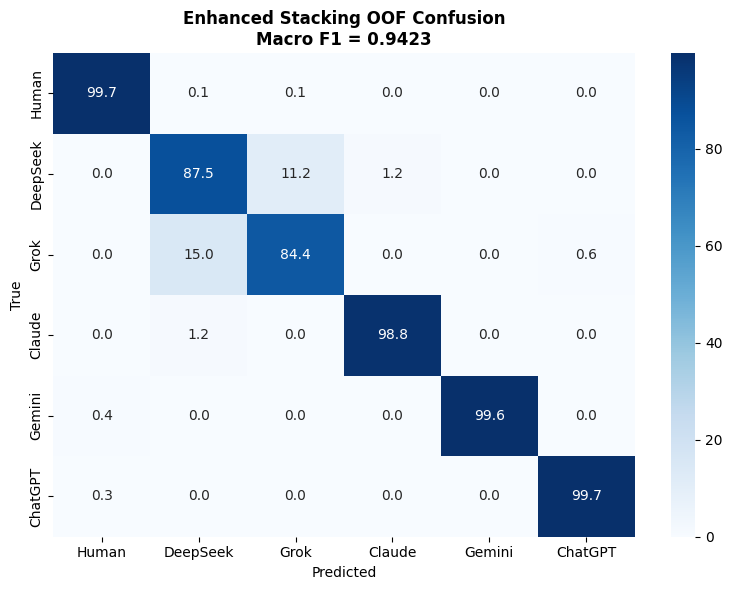

In [13]:
# ============================================================
# PER-CLASS ANALYSIS: WHERE ARE WE LOSING F1?
# ============================================================
print('Per-class OOF F1 — Enhanced Stacking:')
per_class_f1 = f1_score(y_all, best_meta_oof_preds, average=None)
for cls in range(NUM_LABELS):
    n_samples = (y_all == cls).sum()
    print(f'  {LABEL_MAP[cls]:10s} (n={n_samples:4d}): F1={per_class_f1[cls]:.4f}')

print(f'\nMacro F1 = {per_class_f1.mean():.4f}')
print(f'Weakest class: {LABEL_MAP[per_class_f1.argmin()]} (F1={per_class_f1.min():.4f})')

# Confusion matrix
cm = confusion_matrix(y_all, best_meta_oof_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
    xticklabels=[LABEL_MAP[i] for i in range(6)],
    yticklabels=[LABEL_MAP[i] for i in range(6)])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Enhanced Stacking OOF Confusion\nMacro F1 = {best_meta_oof_f1:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/improved_stacking_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# GENERATE AND SAVE IMPROVED SUBMISSIONS
# ============================================================
os.makedirs('submissions', exist_ok=True)

def write_submission(preds, path, name):
    """Write a clean submission file."""
    lines = ['ID,LABEL'] + [f'{i},{int(preds[i])}' for i in range(600)]
    with open(path, 'w', newline='\n') as f:
        f.write('\n'.join(lines) + '\n')
    dist = dict(zip(*np.unique(preds, return_counts=True)))
    print(f'  {name}: {path}')
    print(f'    Distribution: {dist}')
    return path


print('Generating improved submissions...\n')

# Submission 1: Enhanced stacking (best method)
write_submission(stack_test_preds,
    'submissions/v2_enhanced_stacking.csv',
    'Enhanced Stacking')

# Submission 2: Weighted soft vote
write_submission(weighted_test_preds,
    'submissions/v2_weighted_vote.csv',
    f'Weighted Vote ({w_d:.2f}/{w_s:.2f}/{w_l:.2f})')

# Submission 3: DeBERTa only (5-fold)
write_submission(deberta_only_test_preds,
    'submissions/v2_deberta_5fold.csv',
    'DeBERTa 5-Fold Only')

# Submission 4: Simple soft vote
write_submission(soft_vote_preds,
    'submissions/v2_soft_vote.csv',
    'Simple Soft Vote')

# Agreement analysis
print(f'\nAgreement between enhanced stacking and weighted vote:')
agree = (stack_test_preds == weighted_test_preds).mean() * 100
print(f'  {agree:.1f}% ({(stack_test_preds == weighted_test_preds).sum()}/600)')

Generating improved submissions...

  Enhanced Stacking: submissions/v2_enhanced_stacking.csv
    Distribution: {np.int64(0): np.int64(379), np.int64(1): np.int64(28), np.int64(2): np.int64(33), np.int64(3): np.int64(20), np.int64(4): np.int64(60), np.int64(5): np.int64(80)}
  Weighted Vote (0.65/0.25/0.10): submissions/v2_weighted_vote.csv
    Distribution: {np.int64(0): np.int64(379), np.int64(1): np.int64(25), np.int64(2): np.int64(35), np.int64(3): np.int64(20), np.int64(4): np.int64(60), np.int64(5): np.int64(81)}
  DeBERTa 5-Fold Only: submissions/v2_deberta_5fold.csv
    Distribution: {np.int64(0): np.int64(379), np.int64(1): np.int64(26), np.int64(2): np.int64(34), np.int64(3): np.int64(20), np.int64(4): np.int64(60), np.int64(5): np.int64(81)}
  Simple Soft Vote: submissions/v2_soft_vote.csv
    Distribution: {np.int64(0): np.int64(379), np.int64(1): np.int64(21), np.int64(2): np.int64(39), np.int64(3): np.int64(19), np.int64(4): np.int64(61), np.int64(5): np.int64(81)}

Agree

In [15]:
# ============================================================
# SUBMIT TO KAGGLE
# ============================================================
COMPETITION = 'malto-recruitment-hackathon'

# Set up Kaggle auth
os.environ['PATH'] += ':/Users/aliivaezii/Library/Python/3.9/bin'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_b4a6c46509414f03c35239d14c1e1770'

# Submit enhanced stacking (our best)
print('Submitting enhanced stacking...')
cmd = f'kaggle competitions submit -c {COMPETITION} -f submissions/v2_enhanced_stacking.csv -m "V2: Enhanced stacking (DeBERTa 5-fold + SVC + LR), OOF F1={best_meta_oof_f1:.4f}"'
result = os.popen(cmd).read()
print(result)

# Submit weighted vote as diverse option
print('Submitting weighted vote...')
cmd = f'kaggle competitions submit -c {COMPETITION} -f submissions/v2_weighted_vote.csv -m "V2: Weighted soft vote ({w_d:.2f}/{w_s:.2f}/{w_l:.2f}), OOF F1={best_w_f1:.4f}"'
result = os.popen(cmd).read()
print(result)

# Submit DeBERTa only
print('Submitting DeBERTa 5-fold only...')
cmd = f'kaggle competitions submit -c {COMPETITION} -f submissions/v2_deberta_5fold.csv -m "V2: DeBERTa-v3-base 5-fold, OOF F1={deberta_oof_f1:.4f}"'
result = os.popen(cmd).read()
print(result)

print('\nAll V2 submissions sent!')
print('Waiting 30s for scores to populate...')
time.sleep(30)

# Check scores
result = os.popen(f'kaggle competitions submissions -c {COMPETITION}').read()
print(result)

Submitting enhanced stacking...


Python(89349) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Traceback (most recent call last):
  File "/Users/aliivaezii/Documents/MALTO/.venv/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 441, in authenticate
    self._load_config(config_data)
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 492, in _load_config
    raise ValueError


Submitting weighted vote...

Submitting DeBERTa 5-fold only...


Traceback (most recent call last):
  File "/Users/aliivaezii/Documents/MALTO/.venv/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 441, in authenticate
    self._load_config(config_data)
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 492, in _load_config
    raise ValueError('Error: Missing %s in configuration.' % item)
ValueError: Error: Missing key in configuration.
Python(89353) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compi



All V2 submissions sent!
Waiting 30s for scores to populate...



Python(89381) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Traceback (most recent call last):
  File "/Users/aliivaezii/Documents/MALTO/.venv/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 441, in authenticate
    self._load_config(config_data)
  File "/Users/aliivaezii/Documents/MALTO/.venv/lib/python3.9/site-packages/kaggle/api/kaggle_api_extended.py", line 492, in _load_config
    raise ValueError

In [16]:
# ============================================================
# SAVE IMPROVED CONFIG
# ============================================================
v2_config = {
    'version': 'v2',
    'improvements': [
        'DeBERTa 5-fold CV (was single split)',
        'Full OOF coverage: 2400 samples (was 720)',
        'Enhanced meta-features: 36 (was 18)',
        'Optimized meta-learner hyperparameters',
    ],
    'deberta_kfold': {
        'n_folds': N_FOLDS,
        'fold_scores': [float(s) for s in fold_scores],
        'mean_f1': float(np.mean(fold_scores)),
        'oof_f1': float(deberta_oof_f1),
        'temperature': float(best_temp),
    },
    'stacking': {
        'meta_learner': best_meta_name,
        'oof_f1': float(best_meta_oof_f1),
        'n_meta_features': meta_X_oof.shape[1],
    },
    'weighted_vote': {
        'weights': {'deberta': float(w_d), 'svc': float(w_s), 'lr': float(w_l)},
        'oof_f1': float(best_w_f1),
    },
    'comparison': {
        'deberta_only': float(deberta_oof_f1),
        'svc_only': float(svc_oof_f1),
        'lr_only': float(lr_oof_f1),
        'soft_vote': float(soft_vote_oof_f1),
        'weighted_vote': float(best_w_f1),
        'enhanced_stacking': float(best_meta_oof_f1),
        'previous_stacking_phase5': 0.9552,
    },
}

with open('models/v2_improvement_config.json', 'w') as f:
    json.dump(v2_config, f, indent=2)

print('Saved: models/v2_improvement_config.json')
print(f'\n{"="*60}')
print(f'IMPROVEMENT SUMMARY')
print(f'{"="*60}')
print(f'Previous best LB:      0.90974')
print(f'Previous OOF (Phase5): 0.9552 (on 720 samples)')
print(f'New OOF (full 2400):   {best_meta_oof_f1:.4f}')
print(f'Target:                0.95081 (1st place)')

Saved: models/v2_improvement_config.json

IMPROVEMENT SUMMARY
Previous best LB:      0.90974
Previous OOF (Phase5): 0.9552 (on 720 samples)
New OOF (full 2400):   0.9423
Target:                0.95081 (1st place)
